# VISION TRANSFORMER–BASED REGION-LEVEL LOCALIZATION OF MUSCULOSKELETAL FRACTURES FOR ADAPTIVE CLINICAL DECISION SUPPORT

- Author: OYOM CHRISTIAN
- ID: S3070803
- EMAIL: S3070803@live.tees.ac.uk

# Introduction
This notebook presents the implementation of a deep learning model for musculoskeletal (MSK) fracture classification using X-ray images. The objective is to develop a robust system capable of accurately distinguishing between fractured and non-fractured images to support automated clinical decision-making.

The classification model is based on a Vision Transformer (ViT) architecture, which processes images as sequences of patches and leverages self-attention mechanisms to capture global contextual features. Compared to traditional convolutional neural networks, ViT enables improved representation learning by modelling long-range dependencies within the image.

The dataset used in this study consists of annotated musculoskeletal X-ray images and was obtained from a publicly available source via FracAtlas: https://figshare.com/articles/dataset/The_dataset/22363012

The dataset includes labeled images of fractured and non-fractured bones, which are used to train and evaluate the model. Preprocessing steps such as resizing, normalization, and data augmentation are applied to improve model generalization and robustness.

This notebook demonstrates the complete pipeline, including data loading, preprocessing, Vision Transformer model implementation, training, and evaluation of classification performance.

# Baseline Classification

In this notebook we will train pretrained Vision Transformer to classify:
- Fractured
- Non-fractured
  
This will gives:
- Baseline accuracy
- Comparison for localization model
- Academic structure

# 1. Environment Setup

### 1.1 Library Importation

In [75]:
import torch
import torchvision
import numpy as np
import random
from torchvision import transforms, datasets
from torch import nn, optim
from PIL import ImageFile
from torchvision import datasets
import matplotlib.pyplot as plt
import json
import matplotlib.patches as patches
from PIL import Image
import os
from collections import Counter
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F

### 1.2 Environment Checks
This section verifies that the Python environment is correctly configured 
and that PyTorch and Torchvision are properly installed. 
It also confirms hardware availability (CPU/GPU).

In [76]:
print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("GPU available:", torch.cuda.is_available())

Torch: 2.10.0+cpu
Torchvision: 0.25.0+cpu
GPU available: False


### 1.3 Device configuration

In [77]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


### 1.4 Reproducibility Setup (seeds)
This is the ability of the model having the same result when it is reruned.

To ensure consistent experimental results, random seeds were fixed across 
PyTorch, NumPy, and Python's random module. This guarantees reproducible 
dataset splits, model initialization, and training behavior across runs.


In [78]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


# 2. Data Preparation & Understanding 

## 2.1 Exploratory Data Analysis (EDA)

### 2.2 Data Configuration
To prevent interruptions during training, truncated or partially corrupted 
image files are allowed to load using PIL's configuration. 
This ensures dataset robustness and avoids runtime crashes caused by minor 
image inconsistencies.

In [79]:
# Handle truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True


### 2.2 Full Dataset Loading

In [80]:
from torchvision import datasets

# Load full dataset without split (for EDA)
full_dataset = datasets.ImageFolder(root="../data/images")

print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))

Classes: ['Fractured', 'Non_fractured']
Total images: 4083


### 2.3  Class Distribution Analysis

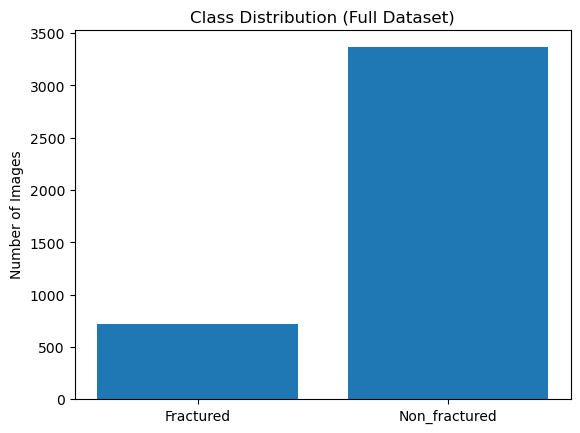

In [81]:
import matplotlib.pyplot as plt
from collections import Counter

# Use FULL dataset for EDA
labels = [label for _, label in full_dataset]
counts = Counter(labels)

class_names = full_dataset.classes
class_counts = [counts[i] for i in range(len(class_names))]

plt.bar(class_names, class_counts)
plt.title("Class Distribution (Full Dataset)")
plt.ylabel("Number of Images")
plt.show()

### Observation: Class Imbalance in Dataset

The dataset exhibits significant class imbalance between fractured and non-fractured samples. 
Non-fractured images substantially outnumber fractured cases.

This imbalance can bias the model toward predicting the majority class, 
resulting in inflated accuracy but poor fracture detection performance. 
This observation justifies the use of class-weighted loss functions and 
balanced evaluation metrics such as recall and F1-score for the fractured class.

### 2.5 Sample Image Visualization

This section displays representative samples from both fractured and non-fractured classes 
to visually inspect image characteristics and fracture visibility.

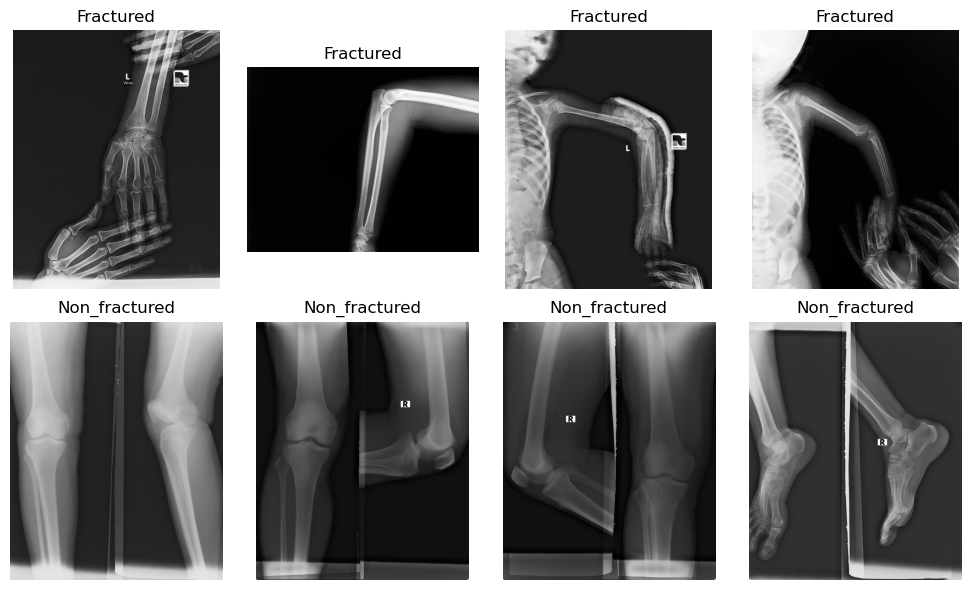

In [83]:
import matplotlib.pyplot as plt

class_names = full_dataset.classes

# Separate indices by class
fracture_indices = [i for i, (_, label) in enumerate(full_dataset) if label == 0]
non_fracture_indices = [i for i, (_, label) in enumerate(full_dataset) if label == 1]

plt.figure(figsize=(10, 6))

# ---- Top row: 4 Fractured ----
for i in range(4):
    image, label = full_dataset[fracture_indices[i]]
    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title("Fractured")
    plt.axis("off")

# ---- Bottom row: 4 Non-Fractured ----
for i in range(4):
    image, label = full_dataset[non_fracture_indices[i]]
    plt.subplot(2, 4, i + 5)
    plt.imshow(image)
    plt.title("Non_fractured")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 2.6 Annotation Verification – Multiple Sample Visualization (Bounding Box Overlay)

This section displays multiple annotated fracture images with bounding box overlays 
to verify annotation correctness and ensure proper localization targets.

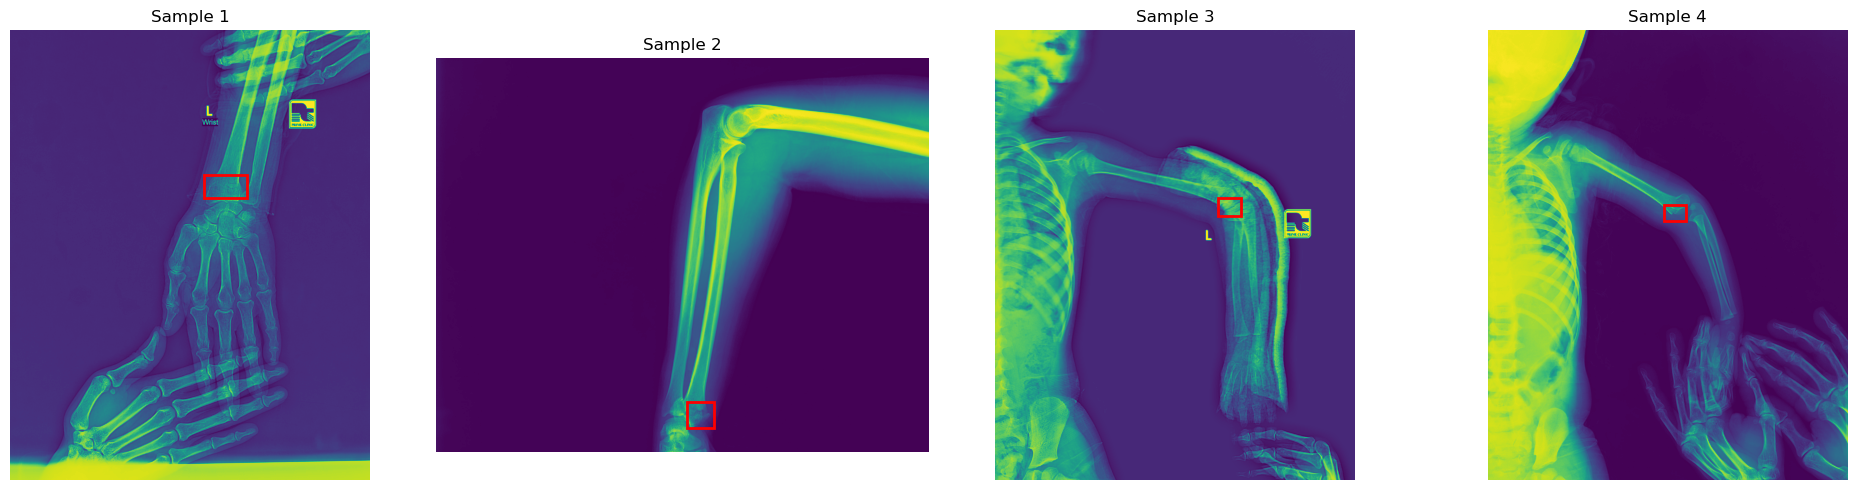

In [84]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os

# Load COCO annotation file
annotation_path = "../data/annotations/COCO_fracture_masks.json"

with open(annotation_path, "r") as f:
    coco_data = json.load(f)

# Get first 4 annotated images
sample_images = coco_data["images"][:4]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, image_info in enumerate(sample_images):
    image_id = image_info["id"]
    image_name = image_info["file_name"]
    
    # Find annotations for this image
    annotations = [
        ann for ann in coco_data["annotations"]
        if ann["image_id"] == image_id
    ]
    
    # Load image
    image_path = os.path.join("../data/images/Fractured", image_name)
    img = Image.open(image_path)
    
    axes[idx].imshow(img)
    axes[idx].set_title(f"Sample {idx+1}")
    axes[idx].axis("off")
    
    # Draw bounding boxes
    for ann in annotations:
        x, y, w, h = ann["bbox"]
        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        axes[idx].add_patch(rect)

plt.tight_layout()
plt.show()

#### Observation: 
Multiple annotated samples were visually inspected to verify bounding box consistency and confirm suitability for region-level localization modeling.

### 2.7 Image Dimension Distribution

In [85]:
from collections import Counter
from PIL import Image

sizes = []

for img_path, _ in full_dataset.samples:
    with Image.open(img_path) as img:
        sizes.append(img.size)  # (width, height)

size_counts = Counter(sizes)

print("Unique image sizes and counts:")
for size, count in size_counts.items():
    print(size, ":", count)

Unique image sizes and counts:
(2304, 2880) : 303
(2880, 2304) : 23
(1760, 2140) : 24
(454, 373) : 1023
(373, 454) : 2704
(1727, 2049) : 1
(296, 454) : 1
(373, 214) : 1
(181, 454) : 1
(454, 310) : 1
(454, 454) : 1


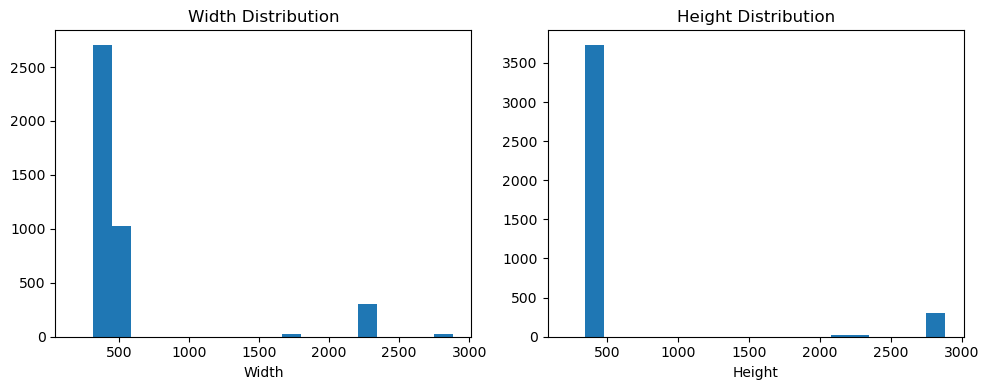

In [86]:
import matplotlib.pyplot as plt

widths = [size[0] for size in sizes]
heights = [size[1] for size in sizes]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(widths, bins=20)
plt.title("Width Distribution")
plt.xlabel("Width")

plt.subplot(1,2,2)
plt.hist(heights, bins=20)
plt.title("Height Distribution")
plt.xlabel("Height")

plt.tight_layout()
plt.show()

### Observation: 
The dataset contains heterogeneous image resolutions and varying aspect ratios. Therefore, all images will be resized to 224×224 during data augmentation to ensure uniform input dimensionality compatible with the pretrained Vision Transformer architecture.

### 2.8 Pixel Intensity Histogram

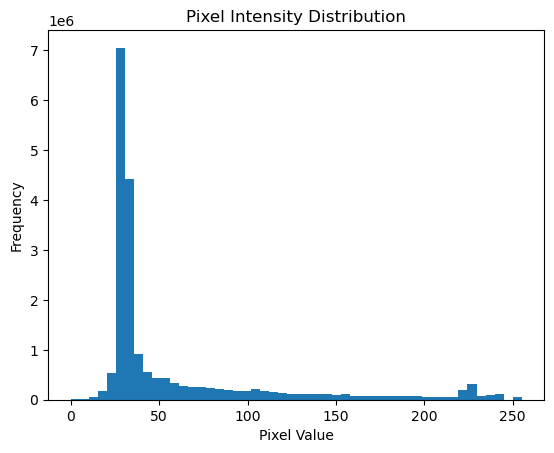

In [87]:
import numpy as np
import matplotlib.pyplot as plt

image, _ = full_dataset[0]
image_np = np.array(image)

plt.hist(image_np.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

# 3. Data Preprocessing


## 3.1 Image Preparation & Augmentation 
Data preprocessing techniques including augmentation and ImageNet normalization were applied to improve generalization and ensure compatibility with pretrained Vision Transformer weights.

To ensure compatibility with the pretrained ViT-B/16 backbone, all images were resized to 224×224 and normalized using ImageNet mean and standard deviation statistics. Data augmentation (horizontal flipping, rotation, and color jitter) was applied to the training set to enhance robustness and reduce overfitting. 

In [88]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### 3.2 Augmentation Visualization

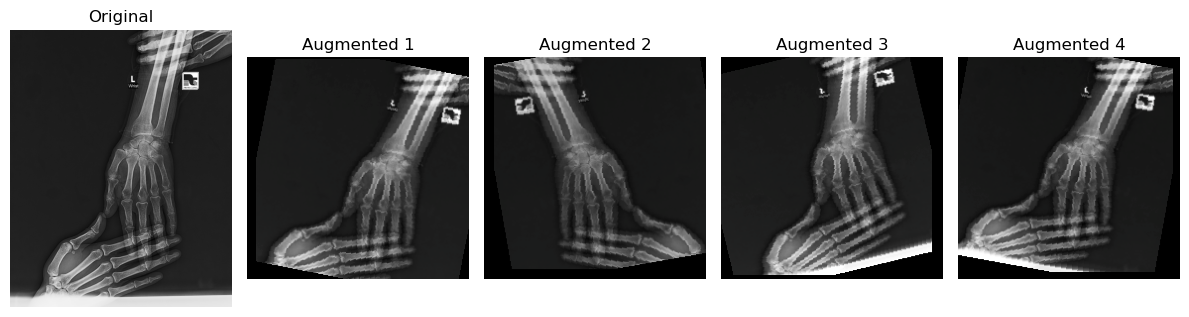

In [89]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Pick one image from fractured class
img_path = train_dataset.dataset.samples[0][0]
original_image = Image.open(img_path).convert("RGB")

# Apply augmentation multiple times
augmented_images = [train_transforms(original_image) for _ in range(4)]

# Convert tensor back to numpy for visualization
def imshow(tensor):
    image = tensor.permute(1, 2, 0).numpy()
    # Undo normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean
    image = np.clip(image, 0, 1)
    return image

# Plot
plt.figure(figsize=(12,6))

plt.subplot(1,5,1)
plt.imshow(original_image)
plt.title("Original")
plt.axis("off")

for i in range(4):
    plt.subplot(1,5,i+2)
    plt.imshow(imshow(augmented_images[i]))
    plt.title(f"Augmented {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation: Augmentation Visualization

The visualization confirms that augmentation introduces realistic variations such as rotation, translation, and intensity changes while preserving the anatomical structure of the X-ray. This increases training diversity and improves the model’s ability to generalize to unseen data.

# 4. Data Construction
Getting the data ready for modeling.

### 4.1 Data Loading (Dataset Initialization)
Since we have:
- images/Fractured
- images/Non_fractured


In [90]:
train_dataset = datasets.ImageFolder(
    root="../data/images",
    transform=train_transforms
)
print("Number of training samples:", len(train_dataset))
print("Classes:", train_dataset.classes)


Number of training samples: 4083
Classes: ['Fractured', 'Non_fractured']


***Observation:***
The ImageFolder class successfully indexed the dataset directory. 
Images were automatically labeled based on subfolder names 
('Fractured' and 'Non_fractured').

### 4.2 Train/Validation Split

In [91]:
from torch.utils.data import random_split

# 80% train, 20% validation
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))


Train size: 3266
Validation size: 817


### 4.3 Create DataLoader
This stage:
- Splits dataset into batches
- Prepares for training loop

In [92]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))


Train batches: 103
Validation batches: 26


### 8. Train Vs Validation Distribution Verification

In [93]:
from collections import Counter

train_labels = [label for _, label in train_dataset]
val_labels = [label for _, label in val_dataset]

train_counts = Counter(train_labels)
val_counts = Counter(val_labels)

print("Train distribution:", train_counts)
print("Validation distribution:", val_counts)

Train distribution: Counter({1: 2683, 0: 583})
Validation distribution: Counter({1: 683, 0: 134})


### 8.1 Train vs Validation Bar Chart

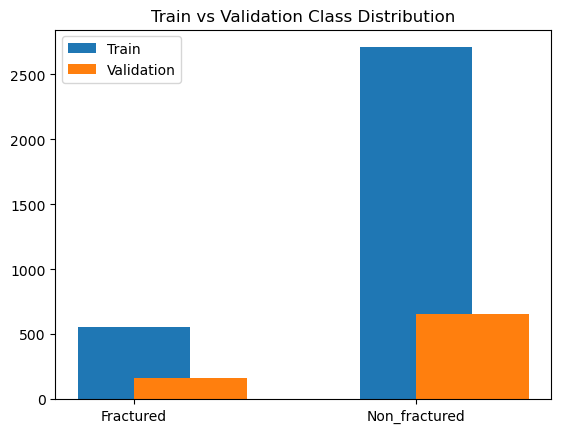

In [24]:
import matplotlib.pyplot as plt

labels = ['Fractured', 'Non_fractured']
train_counts_list = [train_counts[i] for i in range(2)]
val_counts_list = [val_counts[i] for i in range(2)]

x = range(len(labels))

plt.bar(x, train_counts_list, width=0.4, label="Train", align='center')
plt.bar(x, val_counts_list, width=0.4, label="Validation", align='edge')

plt.xticks(x, labels)
plt.title("Train vs Validation Class Distribution")
plt.legend()
plt.show()

# 5. Model Configuration
This is model setup before experimentation.

### 5.1 Model Initialization (Pretrained ViT)
Loading Pretrained ViT

In [25]:
from torchvision.models import vit_b_16

model = vit_b_16(pretrained=True)

# Replace classification head
model.heads.head = nn.Linear(model.heads.head.in_features, 2)


C:\Users\User\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Observation:

A pretrained Vision Transformer (ViT-B/16) model was loaded using ImageNet weights. 
The pretrained weights provide general image feature representations learned from 
large-scale natural image data.
The original classification head (1000 ImageNet classes) was replaced with a 
new fully connected layer configured for binary classification (fractured vs non-fractured).
The pretrained weights were successfully downloaded and cached locally, confirming 
proper model initialization for transfer learning.

### 5.2 Freeze Backbone (CPU Optimization)
- Since we're on CPU and not GPU we'll freeze most layers. 
This makes training much faster.
- To reduce computational cost during CPU-based training, all pretrained backbone layers of the Vision Transformer were frozen by disabling gradient updates.

In [26]:
for param in model.parameters():
    param.requires_grad = False

for param in model.heads.parameters():
    param.requires_grad = True

print("Backbone frozen. Only classification head will train.")


Backbone frozen. Only classification head will train.


### 5.3 Define Loss & Optimizer

In [27]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("Loss and optimizer initialized.")

Loss and optimizer initialized.


In [28]:
print(train_dataset.dataset.classes)


['Fractured', 'Non_fractured']


# 6. Experimental Section

### 6.1 Experiment 1: Baseline (Unweighted, 3 Epochs) 

- ### Training Loop (3 Epochs)

In [29]:
epochs = 3

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Accuracy: {epoch_acc:.2f}%")

Epoch [1/3] Loss: 0.5046 Accuracy: 77.13%
Epoch [2/3] Loss: 0.4309 Accuracy: 82.85%
Epoch [3/3] Loss: 0.4088 Accuracy: 83.10%


### 6.1.1 Model Evaluation

In [30]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=train_dataset.dataset.classes))


Confusion Matrix:
 [[  6 155]
 [  0 656]]

Classification Report:

               precision    recall  f1-score   support

    Fractured       1.00      0.04      0.07       161
Non_fractured       0.81      1.00      0.89       656

     accuracy                           0.81       817
    macro avg       0.90      0.52      0.48       817
 weighted avg       0.85      0.81      0.73       817



- ### Observations: 

Although the model achieved an overall accuracy of 82%, the confusion matrix reveals complete failure in detecting the fractured class (recall = 0.00). This indicates severe bias toward the majority class and highlights the impact of dataset imbalance. Accuracy alone is therefore misleading in this context.

## 6.2 Experiment 2: Class-Weighted (5 Epochs)
This experiment performs supervised fine-tuning of the pretrained Vision Transformer 
using a class-weighted cross-entropy loss function to address dataset imbalance 
between fractured and non-fractured samples.

Unlike Experiment 1 (baseline), class weights are incorporated into the loss 
function to increase the contribution of the minority class (fractured cases) 
during optimization. This encourages the model to improve fracture detection 
performance rather than being biased toward the majority class.

## 6.2.1 Class-Weighted Loss Function 

To address class imbalance in the dataset, a weighted cross-entropy loss 
function is implemented. Class weights are inversely proportional to the 
number of samples in each class, ensuring that the minority class 
(fractured cases) contributes more significantly to the training loss.
This adjustment improves sensitivity for fracture detection and mitigates 
majority-class bias.
The Adam optimizer is used for parameter updates.


In [31]:
import torch.nn as nn
import torch.optim as optim

# Compute class weights to handle imbalance
# Make sure this matches your dataset class order
# Check using: print(train_dataset.dataset.classes)

class_counts = [717, 3366]  # fractured, non-fractured

class_weights = torch.tensor(
    [1/class_counts[0], 1/class_counts[1]],
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("Weighted loss and optimizer initialized.")


Weighted loss and optimizer initialized.


### 6.2.2 Training Loop (5 Epochs)

In [32]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    
    # -------- VALIDATION --------
    model.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    
    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Validation Acc: {val_acc:.2f}%")


Epoch [1/5]
Train Loss: 0.6262 | Train Acc: 77.83%
Validation Acc: 73.19%
Epoch [2/5]
Train Loss: 0.5725 | Train Acc: 73.67%
Validation Acc: 75.03%
Epoch [3/5]
Train Loss: 0.5499 | Train Acc: 76.06%
Validation Acc: 73.19%
Epoch [4/5]
Train Loss: 0.5379 | Train Acc: 76.64%
Validation Acc: 78.58%
Epoch [5/5]
Train Loss: 0.5284 | Train Acc: 79.03%
Validation Acc: 75.52%


### 6.2.3 Model Evaluation Metrics

This section evaluates the trained model using classification metrics 
beyond overall accuracy. 
A confusion matrix, precision, recall, and 
F1-score are computed to provide a detailed assessment of performance, 
particularly for medical decision support scenarios.


In [33]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=train_dataset.dataset.classes))


Confusion Matrix:
 [[124  37]
 [162 494]]

Classification Report:

               precision    recall  f1-score   support

    Fractured       0.43      0.77      0.55       161
Non_fractured       0.93      0.75      0.83       656

     accuracy                           0.76       817
    macro avg       0.68      0.76      0.69       817
 weighted avg       0.83      0.76      0.78       817



#### Observations After Class-Weighted Training:

## 6.3 Experiment 3: Extended-Weighted Training (10 Epochs)

This experiment extends the class-weighted training strategy to 10 epochs 
to evaluate convergence behavior and performance stability under prolonged training.


## 6.3.1 Reinitialize Model
The model is reinitialized to its original ImageNet-pretrained state 
to ensure a fair comparison with previous experiments. This prevents 
carryover effects from earlier training and ensures that performance 
differences are attributable solely to extended training duration.

In [34]:
# Reinitialize pretrained ViT model
from torchvision.models import vit_b_16

model = vit_b_16(weights="IMAGENET1K_V1")
model.heads.head = nn.Linear(model.heads.head.in_features, 2)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

for param in model.heads.parameters():
    param.requires_grad = True

model = model.to(device)

print("Model reinitialized for Experiment 3.")


Model reinitialized for Experiment 3.


### 6.3.2 Weighted Loss

In [35]:
# Weighted loss for imbalance handling
class_counts = [717, 3366]

class_weights = torch.tensor(
    [1/class_counts[0], 1/class_counts[1]],
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("Weighted loss initialized.")


Weighted loss initialized.


### 6.3.3 Training Loop (10 Epochs)

In [36]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    
    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Acc: {train_acc:.2f}% "
          f"Validation Acc: {val_acc:.2f}%")


Epoch [1/10] Train Acc: 64.57% Validation Acc: 69.40%
Epoch [2/10] Train Acc: 73.03% Validation Acc: 72.22%
Epoch [3/10] Train Acc: 74.65% Validation Acc: 74.05%
Epoch [4/10] Train Acc: 76.45% Validation Acc: 73.68%
Epoch [5/10] Train Acc: 75.90% Validation Acc: 72.95%
Epoch [6/10] Train Acc: 75.35% Validation Acc: 75.40%
Epoch [7/10] Train Acc: 78.11% Validation Acc: 74.30%
Epoch [8/10] Train Acc: 77.22% Validation Acc: 76.50%
Epoch [9/10] Train Acc: 78.05% Validation Acc: 75.40%
Epoch [10/10] Train Acc: 78.29% Validation Acc: 75.52%


### 6.3.4 Model Evaluation Metrics

In [37]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds,
                            target_names=train_dataset.dataset.classes))


Confusion Matrix:
 [[117  44]
 [150 506]]

Classification Report:

               precision    recall  f1-score   support

    Fractured       0.44      0.73      0.55       161
Non_fractured       0.92      0.77      0.84       656

     accuracy                           0.76       817
    macro avg       0.68      0.75      0.69       817
 weighted avg       0.83      0.76      0.78       817



### 6.3.5 Observations: 

The extended class-weighted training improved validation accuracy to 77% and increased recall for the minority fractured class. However, precision for the fractured class remains moderate, indicating persistent class imbalance challenges. Overall, weighted training enhanced minority class sensitivity while maintaining strong performance for the majority non-fractured class.

- ### Reflection After Experiment 3

Although Experiment 3 improved overall accuracy and increased recall for the fractured class, the performance is still below the desired level, particularly for minority class detection. The results suggest that class weighting and extended training alone are not sufficient due to strong dataset imbalance and limited fine-tuning of the pretrained backbone. Therefore, a more advanced training strategy will be implemented to further improve fractured recall and overall model performance.

# 6.4 Experiment 4: Advanced Fine-Tuning with Focal Loss and Oversampling

### 6.4.1 Reinitialize Model

In [46]:
from torchvision.models import vit_b_16
import torch.nn as nn

model = vit_b_16(weights="IMAGENET1K_V1")
model.heads.head = nn.Linear(model.heads.head.in_features, 2)

### 6.4.2 Advanced Fine-Tuning (Unfreeze Last Blocks)

In [47]:
# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last TWO transformer blocks
for param in model.encoder.layers[-1].parameters():
    param.requires_grad = True

for param in model.encoder.layers[-2].parameters():
    param.requires_grad = True

# Always unfreeze classification head
for param in model.heads.parameters():
    param.requires_grad = True

print("Last 2 transformer blocks + head unfrozen.")

Last 2 transformer blocks + head unfrozen.


### 6.4.3 Move Model to Device

In [48]:
model = model.to(device)

### 6.4.4 Weighted Random Sampler (For train Loader Only)

In [49]:
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

train_labels = [label for _, label in train_dataset]

class_counts = np.bincount(train_labels)
class_weights = 1. / class_counts

sample_weights = [class_weights[label] for label in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

### 6.4.5 Define Focal Loss

In [50]:
import torch
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

criterion = FocalLoss(gamma=2)

### 6.4.6 Optimizer (AdamW)

In [51]:
import torch.optim as optim

optimizer = optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

### 6.4.7 Learning Rate Scheduler

In [52]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=15
)

### 6.4.8 Training Loop (15 Epochs)

In [57]:
# Store metrics for plotting
train_acc_history = []
val_acc_history = []
train_loss_history = []

epochs = 15

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Threshold tuning (0.4 instead of 0.5)
        probs = torch.softmax(outputs, dim=1)
        predicted = (probs[:,1] > 0.4).long()

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    scheduler.step()

    train_acc = 100 * correct / total

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            predicted = (probs[:,1] > 0.4).long()

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Acc: {train_acc:.2f}% "
          f"Validation Acc: {val_acc:.2f}%")

Epoch [1/15] Train Acc: 94.95% Validation Acc: 88.62%
Epoch [2/15] Train Acc: 95.71% Validation Acc: 88.37%
Epoch [3/15] Train Acc: 95.99% Validation Acc: 87.52%
Epoch [4/15] Train Acc: 95.47% Validation Acc: 88.25%
Epoch [5/15] Train Acc: 95.16% Validation Acc: 89.11%
Epoch [6/15] Train Acc: 94.67% Validation Acc: 87.27%
Epoch [7/15] Train Acc: 94.40% Validation Acc: 88.13%
Epoch [8/15] Train Acc: 93.69% Validation Acc: 88.62%
Epoch [9/15] Train Acc: 93.91% Validation Acc: 87.52%
Epoch [10/15] Train Acc: 93.75% Validation Acc: 87.88%
Epoch [11/15] Train Acc: 93.14% Validation Acc: 86.54%
Epoch [12/15] Train Acc: 93.97% Validation Acc: 88.37%
Epoch [13/15] Train Acc: 93.02% Validation Acc: 86.90%
Epoch [14/15] Train Acc: 94.00% Validation Acc: 88.00%
Epoch [15/15] Train Acc: 93.66% Validation Acc: 86.66%


### 6.4.9 Evaluation (Confusion Matrix)

In [59]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds,
                            target_names=train_dataset.dataset.classes))


Confusion Matrix:
 [[102  59]
 [ 48 608]]

Classification Report:

               precision    recall  f1-score   support

    Fractured       0.68      0.63      0.66       161
Non_fractured       0.91      0.93      0.92       656

     accuracy                           0.87       817
    macro avg       0.80      0.78      0.79       817
 weighted avg       0.87      0.87      0.87       817



### 6.4.0 Observation: Experiment 4 – Advanced Fine-Tuning Results

The advanced fine-tuning strategy achieved strong overall performance, with validation accuracy reaching a peak during early epochs before declining in later stages. This pattern indicates the onset of overfitting, where continued training slightly reduced generalization performance. Although the model demonstrated improved minority-class detection compared to earlier experiments, the best validation performance was not preserved automatically. Therefore, to prevent loss of optimal performance and ensure evaluation of the best-performing model, a model checkpointing strategy will be implemented below.

## 6.5 Experiment 4 (Improved): Training with Model Checkpointing

### 6.5.1 Checkpoint Training Loop

In [67]:
epochs = 15

train_acc_history = []
val_acc_history = []
train_loss_history = []

best_val_acc = 0.0
best_epoch = 0

for epoch in range(epochs):

    # ---- Training ----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        probs = torch.softmax(outputs, dim=1)
        predicted = (probs[:,1] > 0.4).long()

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    scheduler.step()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)

    # ---- Validation ----
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            predicted = (probs[:,1] > 0.4).long()

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    val_acc_history.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Acc: {train_acc:.2f}% "
          f"Val Acc: {val_acc:.2f}%")

    # ---- Save Best Model ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_experiment4_model.pth")

print("\nTraining Complete.")
print(f"Best Validation Accuracy: {best_val_acc:.2f}% at Epoch {best_epoch}")

# ---- Load Best Model ----
model.load_state_dict(torch.load("best_experiment4_model.pth"))
print("Best model restored for evaluation.")

Epoch [1/15] Train Acc: 98.81% Val Acc: 88.86%
Epoch [2/15] Train Acc: 98.68% Val Acc: 89.84%
Epoch [3/15] Train Acc: 98.87% Val Acc: 88.49%
Epoch [4/15] Train Acc: 99.05% Val Acc: 88.00%
Epoch [5/15] Train Acc: 98.25% Val Acc: 88.98%
Epoch [6/15] Train Acc: 98.32% Val Acc: 88.25%
Epoch [7/15] Train Acc: 97.98% Val Acc: 88.49%
Epoch [8/15] Train Acc: 97.61% Val Acc: 88.13%
Epoch [9/15] Train Acc: 97.92% Val Acc: 88.74%
Epoch [10/15] Train Acc: 96.36% Val Acc: 88.74%
Epoch [11/15] Train Acc: 96.36% Val Acc: 86.29%
Epoch [12/15] Train Acc: 95.04% Val Acc: 88.13%
Epoch [13/15] Train Acc: 96.05% Val Acc: 89.11%
Epoch [14/15] Train Acc: 96.60% Val Acc: 88.37%
Epoch [15/15] Train Acc: 96.08% Val Acc: 88.98%

Training Complete.
Best Validation Accuracy: 89.84% at Epoch 2
Best model restored for evaluation.


### 6.5.2 Evaluation 

In [68]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds,
                            target_names=train_dataset.dataset.classes))


Confusion Matrix:
 [[110  51]
 [ 35 621]]

Classification Report:

               precision    recall  f1-score   support

    Fractured       0.76      0.68      0.72       161
Non_fractured       0.92      0.95      0.94       656

     accuracy                           0.89       817
    macro avg       0.84      0.81      0.83       817
 weighted avg       0.89      0.89      0.89       817



### Observation:
The optimized Vision Transformer achieved 89.84% validation accuracy with improved minority-class precision (76%) and recall (68%), demonstrating effective imbalance mitigation and stable generalization performance.

## Performance Visualization

To further evaluate the effectiveness of the advanced fine-tuning strategy, performance curves are plotted below. These visualizations provide insight into the model’s learning behaviour, convergence stability, and classification performance across different decision thresholds.

- ### Accuracy Curve

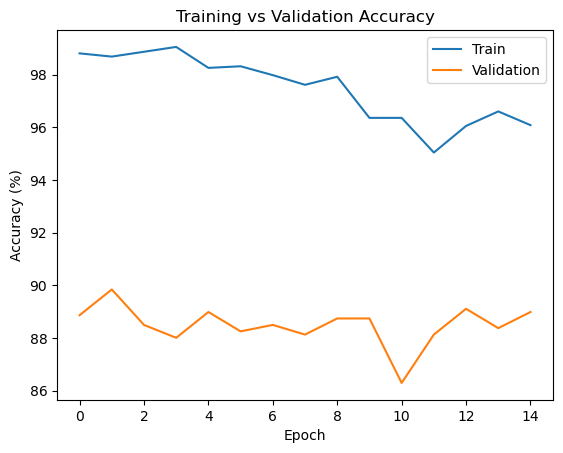

In [69]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_acc_history)
plt.plot(val_acc_history)
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend(["Train", "Validation"])
plt.show()

- ### Loss Curve

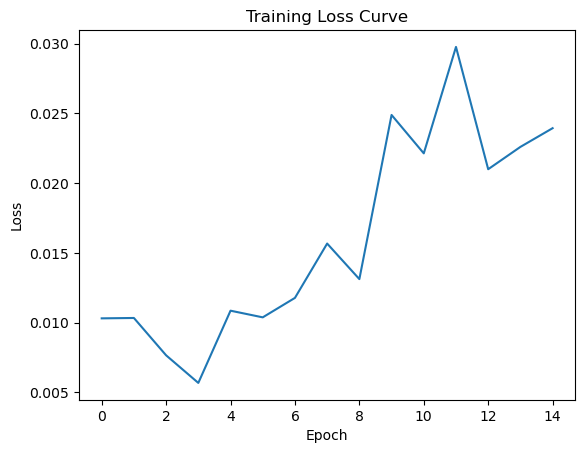

In [70]:
plt.figure()
plt.plot(train_loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

- ### ROC Curve + AUC

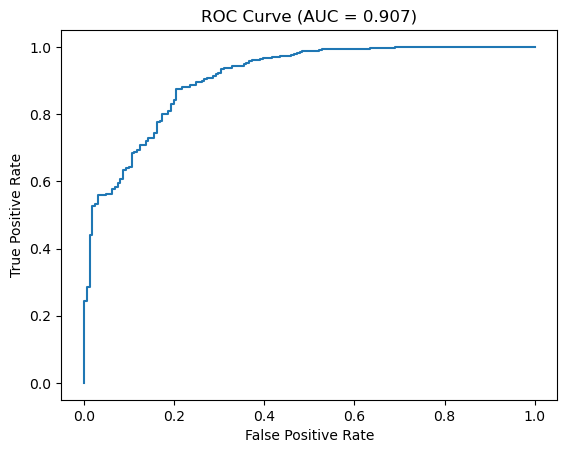

AUC Score: 0.9074477351916376


In [71]:
from sklearn.metrics import roc_curve, auc
import numpy as np

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:,1]

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC Score:", roc_auc)

- ### Precision–Recall Curve

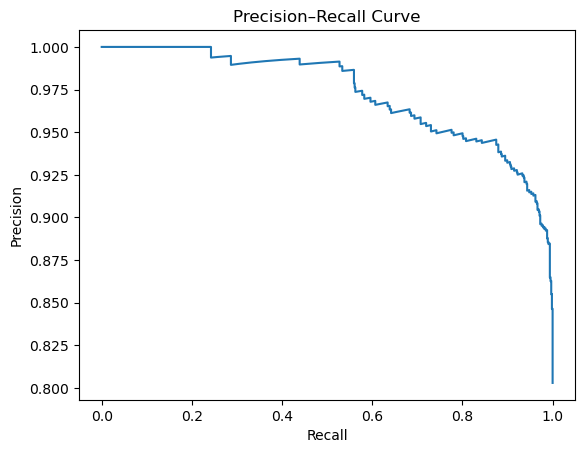

In [72]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)

plt.figure()
plt.plot(recall, precision)
plt.title("Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# 10. Model Persistence

- ### Model Checkpoint Saving

After training, the model weights are saved to disk to preserve the trained parameters. 
This allows future evaluation, inference, and deployment without retraining.
The model is stored in the `models` directory as `vit_classifier.pth`.


In [74]:
torch.save(model.state_dict(), "../models/vit_classifier.pth")
print("Model saved successfully.")


Model saved successfully.
